In [1]:
pip install tensorflow tensorboard

   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.9 MB 4.2 MB/s eta 0:01:20
   ---------------------------------------- 1.0/331.9 MB 3.0 MB/s eta 0:01:52
   ---------------------------------------- 1.6/331.9 MB 2.8 MB/s eta 0:01:59
   ---------------------------------------- 1.8/331.9 MB 2.6 MB/s eta 0:02:09
   ---------------------------------------- 2.6/331.9 MB 2.6 MB/s eta 0:02:07
   ---------------------------------------- 2.9/331.9 MB 2.4 MB/s eta 0:02:20
   ---------------------------------------- 3.4/331.9 MB 2.4 MB/s eta 0:02:18
    --------------------------------------- 4.2/331.9 MB 2.5 MB/s eta 0:02:12
    --------------------------------------- 5.0/331.9 MB 2.6 MB/s eta 0:02:05
    --------------------------------------- 5.8/331.9 MB 2.7 MB/s eta 0:02:00
    --------------------------------------- 6.6/331.9 MB 2.8 MB/s eta 0:01:56
    --------------------------------------- 7.3/331.9 MB 2.9 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.1 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.17.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.33.1 which is incompatible.
tensorflow-intel 2.17.1 requires tensorboard<2.18,>=2.17, but you have tensorboard 2.20.0 which is incompatible.


In [3]:
# Load the TensorBoard notebook extension.
%load_ext tensorboard

In [5]:
# Clear any logs from previous runs
!rm -rf ./logs/

'rm' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
from datetime import datetime
from packaging import version

import tensorflow as tf
from tensorflow import keras
import numpy as np

tf.debugging.experimental.enable_dump_debug_info(
    './logs/',
    tensor_debug_mode="FULL_HEALTH", 
    circular_buffer_size=-1
)

print("TensorFlow version:", tf.__version__)

INFO:tensorflow:Enabled dumping callback in thread MainThread (dump root: ./logs/, tensor debug mode: FULL_HEALTH)
TensorFlow version: 2.20.0


In [11]:
data_size = 1000
train_pct = 0.8
train_size = int(data_size * train_pct)

# Create input data between -1 and 1
x = np.linspace(-1, 1, data_size)
np.random.shuffle(x)

y = 0.8 * (x ** 2) + 0.3 * x + 1.5 + np.random.normal(0, 0.05, data_size)

# Split
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:], y[train_size:]

In [13]:
logdir = "logs/scalars/" + datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=logdir)

In [15]:
keras.layers.Dense(16)
keras.layers.Dense(1)

<Dense name=dense_1, built=False>

In [21]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1),
])


In [23]:
model.compile(
    loss='mse',
    optimizer=keras.optimizers.Adam(learning_rate=0.05),  # modified optimizer
)

In [29]:
training_history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=train_size,
    validation_data=(x_test, y_test),
    callbacks=[tensorboard_callback],
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 2.9817 - val_loss: 1.4415
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - loss: 1.4499 - val_loss: 0.2105
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 0.2144 - val_loss: 1.0163
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.9635 - val_loss: 0.6021
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.5638 - val_loss: 0.0923
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - loss: 0.0801 - val_loss: 0.0426
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.0484 - val_loss: 0.1524
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.1670 - val_loss: 0.2399
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - loss: 0.2574 - val_loss: 0.2562
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 0.2736 - val_loss: 0.2117
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - loss: 0.2271 - val_loss: 0.1388
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 0.1504 - val_loss:

In [27]:
#http://localhost:6006

In [31]:
%tensorboard --logdir logs/

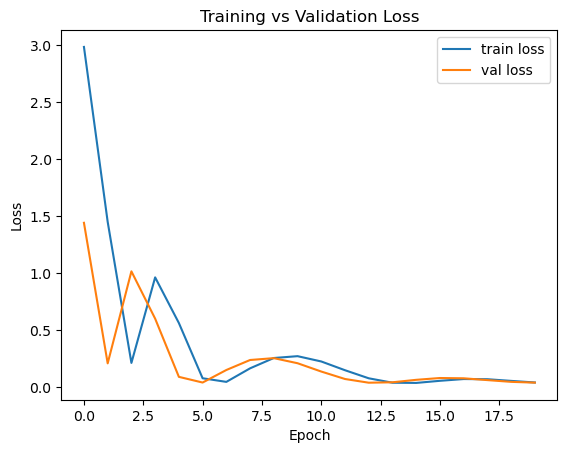

In [33]:
import matplotlib.pyplot as plt

plt.plot(training_history.history['loss'], label='train loss')
plt.plot(training_history.history['val_loss'], label='val loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

A brief overview of the visualizations created in this example and the dashboards (tabs in top navigation bar) where they can be found:

* Scalars show how the loss and metrics change with every epoch. You can use them to also track training speed, learning rate, and other scalar values. Scalars can be found in the Time Series or Scalars dashboards.
* Graphs help you visualize your model. In this case, the Keras graph of layers is shown which can help you ensure it is built correctly. Graphs can be found in the Graphs dashboard.
* Histograms and Distributions show the distribution of a Tensor over time. This can be useful to visualize weights and biases and verify that they are changing in an expected way. Histograms can be found in the Time Series or Histograms dashboards. Distributions can be found in the Distributions dashboard.

Breakdown of the Debugger Interface
The Debugger Dashboard on the Tensorboard consists of five main components:

* __Alerts:__ This top-left section contains a list of alert events detected by the debugger in the debug data from the instrumented TensorFlow program. Each alert indicates a certain anomaly that warrants attention. In our case, this section highlights 499 NaN/∞ events with a salient pink-red color. This confirms our suspicion that the model fails to learn because of the presence of NaNs and/or infinities in its internal tensor values.
* __Python Execution Timeline:__ This is the upper half of the top-middle section. It presents the full history of the eager execution of ops and graphs. Each box of the timeline is marked by the initial letter of the op or graph’s name. We can navigate this timeline by using the navigation buttons and the scrollbar above the timeline.
* __Graph Execution:__ Located at the top-right corner of the GUI, this section will be central to our debugging task. It contains a history of all the floating-type tensors computed inside graphs, i.e., the ones compiled by @tf-functions.
* __Stack Trace:__ The bottom-right section, shows the stack trace of the creation of every single operation on the graph.
* __Source Code:__ The bottom-left section, highlights the source code corresponding to each operation on the graph.
